---
<center>

  # **SOI 220 Zeina**

**By:**

   Samuel Huertas Rojas

---
</center>

In [ ]:
# standard python imports
import os

import gdstk
import matplotlib.pyplot as plt
import numpy as np
from abc import ABC, abstractmethod
from typeguard import typechecked

# tidy3d import
import tidy3d as td
from tidy3d.constants import C_0
from tidy3d import web
from tidy3d.plugins import waveguide
from tidy3d.plugins.mode import ModeSolver
from tidy3d.plugins.mode.web import run as run_mode_solver
from tidy3d import material_library
from tidy3d.plugins.resonance import ResonanceFinder

api_key = "eWyLKylo9YFyULWbODe11KDUhaS4vwPCQaQbEUKRUEOVls5S"
web.configure(api_key)

Configuration saved successfully.


In [ ]:
# Conect GoogleColab with Drive
# from google.colab import drive
# drive.mount('/content/drive')


---

## Design of the structure

This part of the code is based on:
* https://www.flexcompute.com/tidy3d/community/notebooks/DiamondPhotonicCrystalCavity/#

* https://www.flexcompute.com/tidy3d/community/notebooks/SiC1DCavity/

In [ ]:
# Physic parameters
wl_0 = 1.55  # µm

freq_0 = td.C_0 / wl_0

fwidth = 1e13       # source bandwidth (Hz)

# The Gaussian source has an approximate duration of 1/fwidth.
t_pulse = 1 / fwidth   # pulse duration in seconds

# t_start must be large enough for the pulse
# has passed before apodization begins
# General rule: 5 to 10 times the pulse duration
t_start = 5 / fwidth

In [ ]:
wg_width = 0.5 # µm
wg_height = 0.22 # µm

width_bragg_short = 0.348 # µm
width_bragg_long = 0.648 # µm


In [ ]:
# Materials
n_Si = 3.47
n_SiO2 = 1.44
n_Air = 1.0

Air = td.Medium(permittivity=n_Air)
Si = td.Medium(permittivity=n_Si**2)
SiO2 = td.Medium(permittivity=n_SiO2**2)


---

### Auxiliary Functions

In [ ]:
np.random.seed(12)

In [ ]:
from tidy3d.components.types import LengthUnit

# This function is use to create dipole source
def create_source(
    period: float,
    number_p: int,
    polarization="Ey",
    wl1=1.4,
    wl2=1.7,
    center=(0, 0, 0)
):

    # Define the list of the sources
    list_sources = []

    # Length of the Bragg crystal
    total_length_bragg = period * number_p

    # defining the frequencies based on the given wavelengths
    freq1 = td.C_0 / wl1
    freq2 = td.C_0 / wl2
    freq0 = (freq1 - freq2) / 2 + freq2
    fwidth = (freq1 - freq2) / 2

    # defining the source
    source = td.PointDipole(
        center=center,
        name="pointDipole",
        polarization=polarization,
        source_time=td.GaussianPulse(
            freq0=freq0,
            fwidth=fwidth,
            phase=2 * np.pi * np.random.random()
        ),
    )
    list_sources.append(source)

    # definition of the modes measured by the monitor
    mode_spec = td.ModeSpec(
        num_modes=1,
        target_neff=max([n_Si, n_SiO2, n_Air])
    )

    # defining the mode source
    mode_src = td.ModeSource(
        center=(0, 0, - (total_length_bragg + period / 4)),
        name="modeSource",
        size=(td.inf, td.inf, 0),
        source_time=td.GaussianPulse(
            freq0=freq0,
            fwidth=freq0 / 3
          ),
        num_freqs=5,
        direction="+",
        mode_spec=mode_spec,
        mode_index=0,
    )
    list_sources.append(mode_src)

    return list_sources


In [ ]:
def create_monitors(
    simulation,
    monitor_range,
    period:float,
    number_p:int,
    random:bool,
    n_point_monitors=5,
    center=(0, 0, 0),
    deviation=(0.2, 0, 0),
):
    simulation_size = simulation.size

    freq0 = simulation.sources[0].source_time.freq0

    ldas = np.linspace(1.5, 1.6, 101)
    freqs = td.C_0 / ldas

    if random:
      # creating random positions around the center of the cavity
      positions = np.array([
          [center[0], center[1], np.random.uniform(-monitor_range, monitor_range)]
          for _ in range(n_point_monitors)
      ])
    else:
      positions = np.array([
          [center[0], center[1], z]
          for z in np.linspace(-monitor_range, monitor_range, n_point_monitors)
      ])


    # creating the randomly positioned monitors
    point_monitors = [
        td.FieldTimeMonitor(
            center=tuple(positions[i]),
            name=f"pointMon{i}",
            start=0,
            size=(0, 0, 0),
            interval=1,
        )
        for i in range(n_point_monitors)
    ]

    # defining size for the 3D field monitor
    size = tuple(np.array(simulation_size) * 0.9)

    # defining the start time of the monitors to record only the last two oscillations of the field
    start = simulation.run_time - 1 / freq0

    # 3D field monitor for energy density calculation
    field_monitor = td.FieldTimeMonitor(
        center=(0, 0, 0),
        size=size,
        start=start,
        name="fieldTimeMon",
        interval_space=(1, 1, 1),
        interval=10,
    )

    # 2D field monitor for visualizing the resonant mode profile
    field_profile_monitor = td.FieldTimeMonitor(
        center=(0, 0, 0),
        size=(td.inf, td.inf, 0),
        start=start,
        name="fieldProfileMon",
    )

    # setup planar flux monitors surrounding the simulation volume
    flux_monitors = []
    for i in [-1, 1]:
        for j in [(0.5, 0, 0), (0, 0.5, 0), (0, 0, 0.5)]:
            j = np.array(j)
            # defining the center
            mon_center = tuple(np.array(size) * j * i + -1 * i * j * (0.95, 0.95, 0.95))

            # defining the size
            j2 = np.array([0 if l == 0.5 else 1 for l in j])
            mon_size = tuple(np.array(size) * j2 * 2)

            # defining the name
            mon_name = np.array(["x", "y", "z"])[np.ceil(j).astype(bool)][0]
            mon_name = ("-" + mon_name) if i == -1 else mon_name

            # creating the monitors
            flux_monitors.append(
                td.FluxTimeMonitor(center=mon_center, size=mon_size, start=start, name=mon_name)
            )

    # Mode monitor for the propagation of the mode
    mode_monitor = td.ModeMonitor(
        center=(0,0, (period * number_p + period / 4)),
        size=(td.inf, td.inf, 0),
        freqs=freqs,
        mode_spec=td.ModeSpec(num_modes=1, target_neff=max([n_Si, n_SiO2, n_Air])),
        name="mode",
    )

    # Field propagation monitor
    # field_propagation_monitor = td.FieldMonitor(
    #     center=(0, wg_height / 2, 0),
    #     size=(td.inf, 0, td.inf),
    #     freqs=[freq0],
    #     name="fieldPropagationMon",
    # )

    return (
        point_monitors
        + flux_monitors
        + [
            field_monitor,
            field_profile_monitor,
            # field_propagation_monitor,
        ]
        + [mode_monitor]
    )

In [ ]:
# Structure
def create_bragg_structure(
    wg_height: float,
    wg_width: float,
    wg_length: float,
    width_bragg_short: float,
    width_bragg_long: float,
    period: float,
    n_p: int,
    imperfection: bool,
    random_monitors: bool = False,
    center=(0, 0, 0),
    deviation=(0.01, 0.01, 0.01),
    n_point_monitors = 5,
    symm: tuple = (0, 0, 0),
    run_time = 1e-12,
):
    """
    Function to create the structure of the Bragg crystal with the given parameters.
    Args:
    - wg_height: height of the waveguide
    - wg_width: width of the waveguide
    - wg_length: length of the waveguide
    - width_bragg_short: width of the short bragg crystal
    - width_bragg_long: width of the long bragg crystal
    - period: period of the Bragg crystal
    - n_p: number of Bragg crystals
    - center: center of the structure
    - deviation: deviation of the center
    - run_time: run time of the simulation
    - random_monitors: if True, the monitors will be placed randomly around the center
    - n_point_monitors: number of points for the monitors
    - symm: symmetry of the structure
    Returns:
    - simulation: simulation of the structure with monitors
    """
    # ===========================================================
    #              Structure of the Bragg Crystal
    # ===========================================================
    # Length of the each bragg crystal
    length_bragg = period / 2
    total_length_bragg = period * n_p / 2

    list_structures = [] # List of the structures

    if imperfection:
      # Imperfection in the Bragg crystal
      imper_short = td.Structure(
          geometry=td.Box.from_bounds(
            rmin=(-(width_bragg_short / 2), 0, -length_bragg / 2),
            rmax=((width_bragg_short / 2), wg_height, 0)
          ),
          medium=Si,
      )
      imper_long = td.Structure(
          geometry=td.Box.from_bounds(
            rmin=(-(width_bragg_long / 2), 0, 0),
            rmax=((width_bragg_long / 2), wg_height, length_bragg / 2)
          ),
          medium=Si,
      )
      list_structures.append(imper_short)
      list_structures.append(imper_long)

      # Bragg down
      for i in range(0, n_p):
        short_bragg = td.Structure(
            geometry=td.Box.from_bounds(
                rmin=(-(width_bragg_short / 2), 0, ((length_bragg) * 2 * i) - (total_length_bragg * 2 + length_bragg / 2)),
                rmax=((width_bragg_short / 2), wg_height, ((length_bragg) * (2 * i + 1)) - (total_length_bragg * 2 + length_bragg / 2))
            ),
            medium=Si,
        )

        long_bragg = td.Structure(
            geometry=td.Box.from_bounds(
                rmin=(-(width_bragg_long / 2), 0, ((length_bragg) * (2 * i + 1)) - (total_length_bragg * 2 + length_bragg / 2)),
                rmax=((width_bragg_long / 2), wg_height, (length_bragg) + ((length_bragg) * (2 * i + 1)) - (total_length_bragg * 2 + length_bragg / 2))
            ),
            medium=Si,
        )

        list_structures.append(short_bragg)
        list_structures.append(long_bragg)

      # Bragg up
      for i in range(0, n_p):
        short_bragg = td.Structure(
            geometry=td.Box.from_bounds(
                rmin=(-(width_bragg_short / 2), 0, ((length_bragg) * 2 * i) + (length_bragg / 2)),
                rmax=((width_bragg_short / 2), wg_height, ((length_bragg) * (2 * i + 1)) + (length_bragg / 2))
            ),
            medium=Si,
        )

        long_bragg = td.Structure(
            geometry=td.Box.from_bounds(
                rmin=(-(width_bragg_long / 2), 0, ((length_bragg) * (2 * i + 1)) + (length_bragg / 2)),
                rmax=((width_bragg_long / 2), wg_height, (length_bragg) + ((length_bragg) * (2 * i + 1)) + (length_bragg / 2))
            ),
            medium=Si,
        )

        list_structures.append(short_bragg)
        list_structures.append(long_bragg)
      wg_down = td.Structure(
          geometry=td.Box.from_bounds(
            rmin=(-(wg_width / 2), 0, - (total_length_bragg * 2 + length_bragg / 2 + wg_length)),
            rmax=((wg_width / 2), wg_height, - (total_length_bragg * 2 + length_bragg / 2))
          ),
          medium=Si,
      )
      list_structures.append(wg_down)

      wg_up = td.Structure(
          geometry=td.Box.from_bounds(
            rmin=(-(wg_width / 2), 0, (total_length_bragg * 2 + length_bragg / 2)),
            rmax=((wg_width / 2), wg_height, (total_length_bragg * 2 + length_bragg / 2 + wg_length))
          ),
          medium=Si,
      )
      list_structures.append(wg_up)
    else:
      wg_down = td.Structure(
          geometry=td.Box.from_bounds(
            rmin=(-(wg_width / 2), 0, - wg_length),
            rmax=((wg_width / 2), wg_height, - total_length_bragg)
          ),
          medium=Si,
      )
      list_structures.append(wg_down)

      wg_up = td.Structure(
          geometry=td.Box.from_bounds(
            rmin=(-(wg_width / 2), 0, total_length_bragg),
            rmax=((wg_width / 2), wg_height, wg_length)
          ),
          medium=Si,
      )
      list_structures.append(wg_up)

      for i in range(0, n_p):
        short_bragg = td.Structure(
            geometry=td.Box.from_bounds(
                rmin=(-(width_bragg_short / 2), 0, (length_bragg) * 2 * i - total_length_bragg),
                rmax=((width_bragg_short / 2), wg_height, (length_bragg) * (2 * i + 1) - total_length_bragg)
            ),
            medium=Si,
        )

        long_bragg = td.Structure(
            geometry=td.Box.from_bounds(
                rmin=(-(width_bragg_long / 2), 0, (length_bragg) * (2 * i + 1) - total_length_bragg),
                rmax=((width_bragg_long / 2), wg_height, (length_bragg) + (length_bragg) * (2 * i + 1) - total_length_bragg)
            ),
            medium=Si,
        )

        list_structures.append(short_bragg)
        list_structures.append(long_bragg)

    # Combine the structures
    combined_structure = td.Structure(
        geometry=td.GeometryGroup(geometries= [s.geometry for s in list_structures]),
        medium=Si
    )

    # ===========================================================
    #                   Simulation Settings
    # ===========================================================
    margin = wl_0 / 2

    # Size of the simulation
    size_x = width_bragg_long + wg_width * 2 + margin * 2
    size_y = wg_height * 4 + margin * 2
    size_z = period * n_p * 2  + wg_length / 2

    if imperfection:
      poss_monitor_field = total_length_bragg * 2 + length_bragg / 2
    else:
      poss_monitor_field = total_length_bragg * 2

    # ===========================================================
    #                   Source Settings
    # ===========================================================
    sources = create_source(
        period=period,
        number_p=n_p,
        polarization="Ey",
        wl1=1.4,
        wl2=1.7,
        center=(0, wg_height / 2, - (total_length_bragg))
    )

    # ===========================================================
    #                   Simulation Setup
    # ===========================================================
    # Create simulation
    sim = td.Simulation(
        center = (0, 0, 0),
        size=(size_x, size_y, size_z),
        grid_spec=td.GridSpec.auto(
            min_steps_per_wvl=20,
            wavelength=wl_0
        ),
        boundary_spec=td.BoundarySpec.all_sides(boundary=td.PML()),
        run_time=run_time,
        structures=[combined_structure],
        sources=sources,
        monitors=[],
        shutoff=0,
        symmetry=symm,
    )

    # ===========================================================
    #                   Monitors Setup
    # ===========================================================
    # add monitors to the simulation
    monitors = create_monitors(
        simulation=sim,
        monitor_range=length_bragg,
        period=period,
        number_p=n_p,
        random=random_monitors,
        n_point_monitors=n_point_monitors,
        center=(0, wg_height / 2, 0),
        deviation=(0.5, 0, 0)
    )
    return sim.updated_copy(monitors=monitors)

In [ ]:
period_bragg = 0.354
number_p = 46

sim_bragg = create_bragg_structure(
    wg_height=wg_height,
    wg_width=wg_width,
    wg_length=10,
    width_bragg_short=width_bragg_short,
    width_bragg_long=width_bragg_long,
    random_monitors=False,
    period=period_bragg,
    n_p=number_p,
    n_point_monitors=8,
    imperfection=True,
    center=(0, wg_height / 2, 0),
)


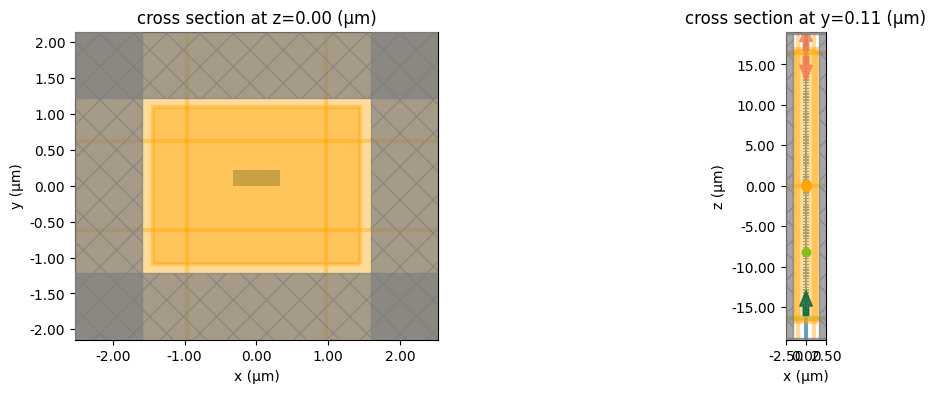

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
sim_bragg.plot(z=0, ax=ax1);
sim_bragg.plot(y=wg_height / 2, ax=ax2);

In [ ]:
sim_bragg.plot_3d(width=1000, height=500)

In [ ]:
# Export simulation to gds
file_name = f"bragg_crystal-{period_bragg * 1000:.1f}-{number_p}.gds"
sim_bragg.to_gds_file(fname=file_name, y=0, permittivity_threshold=6, frequency=200e14)

In [ ]:
# Calculate the cost of the simulation
job = web.Job(simulation=sim_bragg, task_name="brag_crystal", verbose=True)
estimated_cost = web.estimate_cost(job.task_id)

18:17:31 UTC Created task 'brag_crystal' with resource_id                       
             'fdve-fe190c31-eabd-4d64-b399-6648977fa2b7' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=961162;https://tidy3d.simulation.cloud/workbench?taskId=fdve-fe190c31-eabd-4d64-b399-6648977fa2b7\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=679927;https://tidy3d.simulation.cloud/workbench?taskId=fdve-fe190c31-eabd-4d64-b399-6648977fa2b7\taskId]8;;\]8;id=961162;https://tidy3d.simulation.cloud/workbench?taskId=fdve-fe190c31-eabd-4d64-b399-6648977fa2b7\=]8;;\]8;id=955184;https://tidy3d.simulation.cloud/workbench?taskId=fdve-fe190c31-eabd-4d64-b399-6648977fa2b7\fdve]8;;\]8;id=961162;https://tidy3d.simulation.cloud/workbench?taskId=fdve-fe190c31-eabd-4d64-b399-6648977fa2b7\-fe190c31-eab]8;;\
             ]8;id=961162;https://tidy3d.simulation.cloud/workbench?taskId=fdve-fe190c31-eabd-4d64-b399-6648977fa2b7\d-4d64-b399-6648977fa2b7']8;;\.

             Task folder: ]8;id=948630;https://tidy3d.simulation.cloud/folders/folder-a7b4ef25-6bcb-4f64-9241-809188799104\'default']8;;\.

Output()

18:17:33 UTC Estimated FlexCredit cost: 0.101. Minimum cost depends on task     
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

In [ ]:
sim_data = job.run(path="data/simulation_data.hdf5")

18:17:36 UTC status = queued

             To cancel the simulation, use 'web.abort(task_id)' or              
             'web.delete(task_id)' or abort/delete the task in the web UI.      
             Terminating the Python script will not stop the job running on the 
             cloud.

Output()

18:17:49 UTC status = preprocess

18:17:54 UTC You are running this simulation for FREE. Your current plan allows 
             up to 20 free non-concurrent simulations per day (under 100.0M grid
             points and 50.0K time steps)

...

18:19:03 UTC status = success

18:19:05 UTC View simulation result at                                          
             ]8;id=252028;https://tidy3d.simulation.cloud/workbench?taskId=fdve-fe190c31-eabd-4d64-b399-6648977fa2b7\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=620837;https://tidy3d.simulation.cloud/workbench?taskId=fdve-fe190c31-eabd-4d64-b399-6648977fa2b7\taskId]8;;\]8;id=252028;https://tidy3d.simulation.cloud/workbench?taskId=fdve-fe190c31-eabd-4d64-b399-6648977fa2b7\=]8;;\]8;id=3123;https://tidy3d.simulation.cloud/workbench?taskId=fdve-fe190c31-eabd-4d64-b399-6648977fa2b7\fdve]8;;\]8;id=252028;https://tidy3d.simulation.cloud/workbench?taskId=fdve-fe190c31-eabd-4d64-b399-6648977fa2b7\-fe190c31-eab]8;;\
             ]8;id=252028;https://tidy3d.simulation.cloud/workbench?taskId=fdve-fe190c31-eabd-4d64-b399-6648977fa2b7\d-4d64-b399-6648977fa2b7']8;;\.

Output()

18:19:52 UTC Loading results from data/simulation_data.hdf5

18:19:53 UTC WARNING: Warning messages were found in the solver log. For more   
             information, check 'SimulationData.log' or use                     
             'web.download_log(task_id)'.                                       

## Mode volumne calculation

$$
V_{eff} = \dfrac{\int \epsilon (r) |E(r)|^2 d^3 r}{max[\epsilon (r) |E(r)|)]}
$$

Taken from: https://www.flexcompute.com/tidy3d/examples/notebooks/NanobeamCavity/#Mode-Volume-Calculation

In [ ]:
def analyse_resonance_monitors(sim_data, start_time=1e-12, freq_window=None):
    # importing needed libraries
    from tidy3d.plugins.resonance import ResonanceFinder

    combinedSignal = 0
    polarization = sim_data.simulation.sources[0].polarization

    # iterate through all monitors and combine the signal
    i = 0
    name = f"pointMon{i}"
    while name in sim_data.monitor_data:
        combinedSignal += sim_data["pointMon0"].field_components[polarization].squeeze()
        i += 1
        name = f"pointMon{i}"

    # create the ResonanceFinder instance
    rf = ResonanceFinder(freq_window=freq_window)

    # boolean mask to set the data after source decay
    bm = combinedSignal.t >= start_time

    # data containing the resonance information
    data = rf.run_raw_signal(combinedSignal[bm], sim_data.simulation.dt)

    # creating a DataFrame
    df = data.to_dataframe()
    df["wl"] = (td.C_0 / df.index) * 10**3

    return df, combinedSignal

In [ ]:
def find_source_decay(source):
    # source bandwidth
    fwidth = source.source_time.fwidth

    # time offset to start the source
    time_offset = source.source_time.offset / (2 * np.pi * fwidth)

    # time width for a gaussian pulse
    pulse_time = 0.44 / fwidth

    decay_time = time_offset + pulse_time
    return decay_time

In [ ]:
sim = sim_bragg

# defining the frequency window
freq0 = sim_data.simulation.sources[0].source_time.freq0
fwidth = sim_data.simulation.sources[0].source_time.fwidth
freq_window = (freq0 - fwidth / 2, freq0 + fwidth / 2)

# start time to analyze the exponential decaying fields after source decay
start_time = 2 * find_source_decay(
    sim.sources[0],
)

df, signal = analyse_resonance_monitors(sim_data, start_time, freq_window)
df.head(10)


,decay,Q,amplitude,phase,error,wl
freq,,,,,,
1.875389e+14,4.435967e+13,13.281678,107.007079,-2.173329,0.214000,1598.561453
2.033244e+14,2.049141e+12,311.721990,3.755307,1.253547,0.048036,1474.454029
2.046789e+14,2.355803e+12,272.950564,7.691655,-1.884614,0.036938,1464.696353
2.075601e+14,3.553177e+13,18.351727,1087.851149,1.477589,0.078325,1444.364375
2.158291e+14,3.171908e+12,213.766367,393.510509,-1.418964,0.067388,1389.026986


In [ ]:
def get_energy_density(sim_data, sim):
    # retrieving monitor data
    Efield = sim_data["fieldTimeMon"]

    # retrieving permittivity data and interpolating it at the same grid points of the monitor data
    eps = abs(sim.epsilon(box=td.Box(center=(0, 0, 0), size=(td.inf, td.inf, td.inf))))
    eps = eps.interp(coords=dict(x=Efield.Ex.x, y=Efield.Ex.y, z=Efield.Ex.z))

    # calculating the energy density
    energy_density = np.abs(Efield.Ex**2 + Efield.Ey**2 + Efield.Ez**2) * eps

    # calculating the temporal mean value
    delta_t = energy_density.t[-1] - energy_density.t[0]  # signal duration
    energy_density_temporal_mean = energy_density.integrate(coord=("t")) / delta_t

    return energy_density_temporal_mean, eps

In [ ]:
energy_density, eps = get_energy_density(
    sim_data=sim_data,
    sim=sim_bragg
)

In [ ]:
def mode_volume(energy_density, eps):
    # volume integral of the energy density
    Integrated = np.abs(energy_density).integrate(coord=("x", "y", "z"))

    # scaling factor to present in common units of (wl/n)^3
    wl = abs(df.sort_values("Q").iloc[-1]["wl"] / 1000)  # um
    index = np.sqrt(abs(eps.max()))

    Vmode = Integrated / np.max(energy_density) / (wl / index) ** 3

    return Vmode

In [ ]:
Vmode = mode_volume(energy_density, eps)
print(f"Mode volume: {Vmode:.2f} (lambda/n)^3")

Mode volume: 7.96 (lambda/n)^3


---

### Table of Mode Volumne

In [ ]:
list_perioid = [0.348, 0.354]
list_number_p = list(range(30, 54, 2))
table_mode_volume = {}


for period in list_perioid:

  for number_p in list_number_p:
    sim_bragg_table = create_bragg_structure(
        wg_height=wg_height,
        wg_width=wg_width,
        wg_length=10,
        width_bragg_short=width_bragg_short,
        width_bragg_long=width_bragg_long,
        random_monitors=True,
        period=period,
        n_p=number_p,
        n_point_monitors=8,
        imperfection=True,
        center=(0, wg_height / 2, 0),
    )
    # Running the simulation
    job = web.Job(simulation=sim_bragg_table, task_name="brag_crystal", verbose=True)
    sim_data = job.run(path="data/simulation_data.hdf5")

    sim = sim_bragg_table

    # defining the frequency window
    freq0 = sim_data.simulation.sources[0].source_time.freq0
    fwidth = sim_data.simulation.sources[0].source_time.fwidth
    freq_window = (freq0 - fwidth / 2, freq0 + fwidth / 2)

    # start time to analyze the exponential decaying fields after source decay
    start_time = 2 * find_source_decay(
        sim.sources[0],
    )

    df, signal = analyse_resonance_monitors(sim_data, start_time, freq_window)

    energy_density, eps = get_energy_density(
        sim_data=sim_data,
        sim=sim
    )

    Vmode = mode_volume(energy_density, eps)
    # Save results in the dictionary
    key = (period, number_p)
    table_mode_volume[key] = {
        "period": period,
        "number_periods": number_p,
        "mode_volume": Vmode,
    }


17:27:42 UTC Created task 'brag_crystal' with resource_id                       
             'fdve-0db2d263-10c2-4894-8702-00789e074b10' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=847688;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0db2d263-10c2-4894-8702-00789e074b10\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=211751;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0db2d263-10c2-4894-8702-00789e074b10\taskId]8;;\]8;id=847688;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0db2d263-10c2-4894-8702-00789e074b10\=]8;;\]8;id=318541;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0db2d263-10c2-4894-8702-00789e074b10\fdve]8;;\]8;id=847688;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0db2d263-10c2-4894-8702-00789e074b10\-0db2d263-10c]8;;\
             ]8;id=847688;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0db2d263-10c2-4894-8702-00789e074b10\2-4894-8702-00789e074b10']8;;\.

             Task folder: ]8;id=481335;https://tidy3d.simulation.cloud/folders/folder-a7b4ef25-6bcb-4f64-9241-809188799104\'default']8;;\.

Output()

17:27:45 UTC Estimated FlexCredit cost: 0.055. Minimum cost depends on task     
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

...

17:47:34 UTC status = postprocess

17:47:43 UTC status = success

17:47:45 UTC View simulation result at                                          
             ]8;id=80505;https://tidy3d.simulation.cloud/workbench?taskId=fdve-898e3ab1-bdf7-467f-ba9d-e7601533e483\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=157379;https://tidy3d.simulation.cloud/workbench?taskId=fdve-898e3ab1-bdf7-467f-ba9d-e7601533e483\taskId]8;;\]8;id=80505;https://tidy3d.simulation.cloud/workbench?taskId=fdve-898e3ab1-bdf7-467f-ba9d-e7601533e483\=]8;;\]8;id=770485;https://tidy3d.simulation.cloud/workbench?taskId=fdve-898e3ab1-bdf7-467f-ba9d-e7601533e483\fdve]8;;\]8;id=80505;https://tidy3d.simulation.cloud/workbench?taskId=fdve-898e3ab1-bdf7-467f-ba9d-e7601533e483\-898e3ab1-bdf]8;;\
             ]8;id=80505;https://tidy3d.simulation.cloud/workbench?taskId=fdve-898e3ab1-bdf7-467f-ba9d-e7601533e483\7-467f-ba9d-e7601533e483']8;;\.

Output()

17:48:10 UTC Loading simulation from data/simulation_data.hdf5

In [ ]:
import pandas as pd
from IPython.display import display

# Convertir el diccionario a DataFrame
df_mode_volume = pd.DataFrame.from_dict(
    table_mode_volume,
    orient="index"
).reset_index(drop=True)

# Renombrar columnas
df_mode_volume.columns = ["Period (μm)", "Number of Periods", "Mode Volume (V_mode)"]

# Mostrar en el notebook
display(
    df_mode_volume.style
    .format({
        "Period (μm)": "{:.3f}",
        "Mode Volume (V_mode)": "{:.3f}",
    })
    .background_gradient(subset=["Mode Volume (V_mode)"], cmap="viridis")
    .set_caption("Results: effective Mode Volumen vs Bragg Grating Parameters")
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold")]}
    ])
)

,Period (μm),Number of Periods,Mode Volume (V_mode)
0,0.348,30,5.864
1,0.348,32,6.651
2,0.348,34,6.738
3,0.348,36,5.875
4,0.348,38,4.733
5,0.348,40,6.406
6,0.348,42,7.667
7,0.348,44,10.856
8,0.348,46,8.647
9,0.348,48,7.747


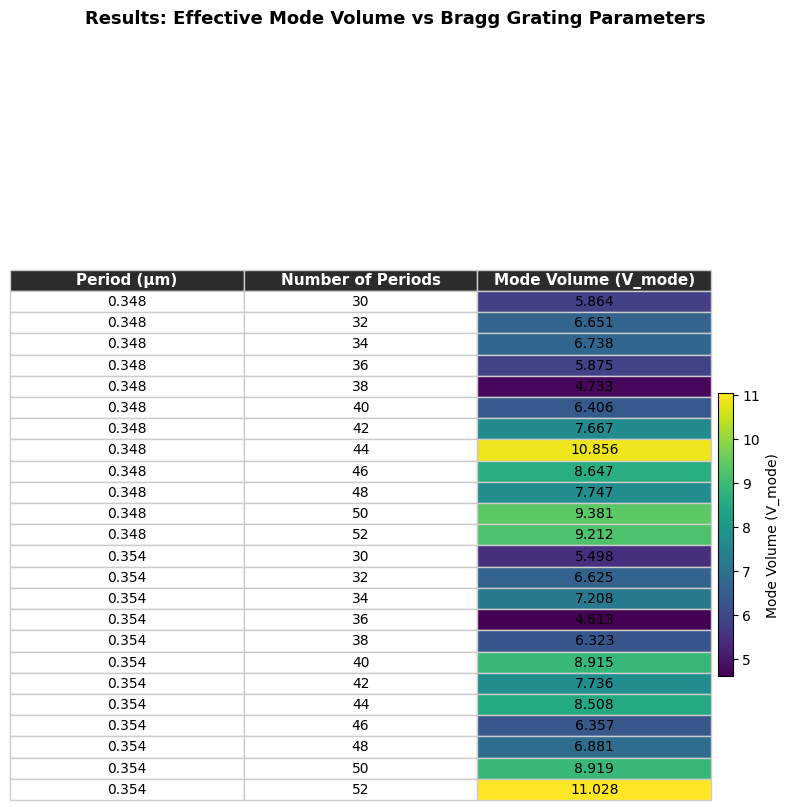

✅ Imagen guardada como mode_volume_table.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Datos
periods = df_mode_volume["Period (μm)"]
n_periods = df_mode_volume["Number of Periods"]
vmode = df_mode_volume["Mode Volume (V_mode)"]

# Normalizar colores como viridis
norm = mcolors.Normalize(vmin=vmode.min(), vmax=vmode.max())
cmap = plt.cm.viridis
cell_colors = [["white", "white", cmap(norm(v))] for v in vmode]

fig, ax = plt.subplots(figsize=(8, len(df_mode_volume) * 0.4 + 1))
ax.axis("off")

table = ax.table(
    cellText=[
        [f"{p:.3f}", f"{n}", f"{v:.3f}"]
        for p, n, v in zip(periods, n_periods, vmode)
    ],
    colLabels=["Period (μm)", "Number of Periods", "Mode Volume (V_mode)"],
    cellColours=cell_colors,
    colColours=["#2c2c2c"] * 3,
    loc="center",
    cellLoc="center",
)

# Estilo encabezados
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(color="white", fontweight="bold", fontsize=11)
        cell.set_facecolor("#2c2c2c")
    else:
        cell.set_text_props(fontsize=10)
    cell.set_edgecolor("#cccccc")
    cell.set_height(0.05)

table.auto_set_font_size(False)
table.scale(1, 1.5)

plt.suptitle(
    "Results: Effective Mode Volume vs Bragg Grating Parameters",
    fontsize=13,
    fontweight="bold",
    y=0.98
)

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation="vertical", fraction=0.02, pad=0.01)
cbar.set_label("Mode Volume (V_mode)", fontsize=10)

plt.tight_layout()
plt.savefig("mode_volume_table.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Imagen guardada como mode_volume_table.png")

---

## Field propagation

In [ ]:
# --- Function for filtering resonances ---
def filter_resonances(resonance_data, minQ, minamp, maxerr):
    resonance_data = resonance_data.where(abs(resonance_data.Q) > minQ, drop=True)
    resonance_data = resonance_data.where(resonance_data.amplitude > minamp, drop=True)
    resonance_data = resonance_data.where(resonance_data.error < maxerr, drop=True)
    resonance_data = resonance_data.where(resonance_data.freq > 0, drop=True)
    return resonance_data


In [ ]:
# --- Function to convert from freq to nm ---
def freq_nm(freq):
    return (td.C_0 / freq) * 1e3

# --- Function to convert from nm to freq ---
def m_freq(m):
    return (td.C_0 / m)

In [ ]:
# --- Function to find the cavity mode ---
def cavitymode(resonance_data):
    freq = resonance_data.freq
    nm = freq_nm(freq)
    Q = resonance_data.Q
    amplitude = resonance_data.amplitude
    cost = (amplitude * Q) / (np.pi * nm)
    idx = cost.argmax()
    return float(freq[idx]), float(Q[idx])

In [ ]:
# Frequency range of interest
ss0 = td.C_0 / (700e-3)
ss1 = td.C_0 / (400e-3)
ss2 = td.C_0 / (1000e-3)
ss3 = td.C_0 / (1500e-3)
ss4 = td.C_0 / (1600e-3)
ss5 = td.C_0 / (2000e-3)

ssWidth = 149999999997498 / 2.35
# ssWidth = (3e8 / 1550e-9) * (100 / 1550)

# Runtime
runtime = 800 / ssWidth
tstart = 5 / ssWidth

### Simulation of a single cell of a Bragg grating

In [ ]:
# Function of a single cell of a Bragg grating
def uniform_bragg_cell(
    period: float,
    width_bragg_short: float,
    width_bragg_long: float,
):
    """
    Creates a single unit cell of a Bragg crystal reflector with two symmetric halves
    that can have different widths.

    Each half of the cell spans period/2 along the x-axis. The left segment (negative x)
    uses width_bragg_short, while the right segment (positive x) uses width_bragg_long.
    Both segments are made of silicon and merged into a single Tidy3D Structure via a
    GeometryGroup. Unlike uniform_bragg_cell_imperfection, each segment here spans the
    full half-period (period/2) rather than a quarter-period, resulting in a larger cell.

    Parameters
    ----------
    period : float
        The full period of the Bragg grating. Each half-segment has length period/2.
    width_bragg_short : float
        Width (y-extent) of the left/negative-x segment, centered on y=0.
    width_bragg_long : float
        Width (y-extent) of the right/positive-x segment, centered on y=0.

    Returns
    -------
    td.Structure
        A single Tidy3D Structure containing both silicon segments grouped together,
        ready to be placed and repeated in a larger Bragg grating simulation.
    """
    length_bragg = period / 2
    list_structures = []

    # Creation of a cell of the bragg crystal
    short_bragg = td.Structure(
        geometry= td.Box.from_bounds(
            # rmin=(-(length_bragg), -(width_bragg_short / 2), 0),
            rmin=(- 10, -(width_bragg_short / 2), 0),
            rmax=(0, (width_bragg_short / 2), wg_height)
            # rmin=(0, -(width_bragg_short / 2), 0),
            # rmax=((length_bragg), (width_bragg_short / 2), wg_height)
        ),
        medium=Si,
    )

    long_bragg = td.Structure(
        geometry=td.Box.from_bounds(
            rmin=(0, -(width_bragg_long / 2), 0),
            # rmax=((length_bragg), (width_bragg_long / 2), wg_height)
            rmax=(10, (width_bragg_long / 2), wg_height)
            # rmin=((length_bragg), -(width_bragg_short / 2), 0),
            # rmax=((2 * length_bragg), (width_bragg_short / 2), wg_height)
        ),
        medium=Si,
    )


    list_structures.append(short_bragg)
    list_structures.append(long_bragg)

    # Convert the list of structures in only one
    combined_structure = td.Structure(
        geometry=td.GeometryGroup(geometries= [s.geometry for s in list_structures]),
        medium=Si
    )

    return combined_structure

# Function of a single cell of the imperfection in the Bragg crystal
def uniform_bragg_cell_imperfection(
    period: float,
    width_bragg_short: float,
    width_bragg_long: float,
):
    """
    Creates a single unit cell of a Bragg crystal reflector with intentional width
    asymmetry between its two halves, simulating a geometric imperfection.

    Each half of the cell spans period/4 along the x-axis. The left segment (negative x)
    uses width_bragg_short, while the right segment (positive x) uses width_bragg_long.
    Both segments are made of silicon and merged into a single Tidy3D Structure via a
    GeometryGroup. When both widths are equal, the cell is perfectly uniform; differences
    between them introduce a structural imperfection that can model fabrication tolerances
    or intentional apodization effects.

    Parameters
    ----------
    period : float
        The full period of the Bragg grating. Each half-segment has length period/4.
    width_bragg_short : float
        Width (y-extent) of the left/negative-x segment, centered on y=0.
    width_bragg_long : float
        Width (y-extent) of the right/positive-x segment, centered on y=0.

    Returns
    -------
    td.Structure
        A single Tidy3D Structure containing both silicon segments grouped together,
        ready to be placed and repeated in a larger Bragg grating simulation.
    """
    length_bragg = period / 4
    list_structures = []

    # Creation of a cell of the bragg crystal
    short_bragg = td.Structure(
        geometry= td.Box.from_bounds(
            # rmin=( - (length_bragg), -(width_bragg_short / 2), 0),
            rmin=( - 10, -(width_bragg_short / 2), 0),
            rmax=(0, (width_bragg_short / 2), wg_height)
        ),
        medium=Si,
    )

    long_bragg = td.Structure(
        geometry=td.Box.from_bounds(
            rmin=(0, -(width_bragg_long / 2), 0),
            # rmax=((length_bragg), (width_bragg_long / 2), wg_height)
            rmax=(10, (width_bragg_long / 2), wg_height)
        ),
        medium=Si,
    )

    list_structures.append(short_bragg)
    list_structures.append(long_bragg)

    # Convert the list of structures in only one
    combined_structure = td.Structure(
        geometry=td.GeometryGroup(geometries= [s.geometry for s in list_structures]),
        medium=Si
    )

    return combined_structure

In [ ]:
def make_cells(
    params: dict,
):
    """
    Creates the simulation components for a Bragg crystal structure in Tidy3D.

    Parameters
    ----------
    params : dict
        Dictionary containing the simulation parameters:
        - period (float): Lattice constant (periodicity) of the structure along x.
        - w_bragg_short (float): Width of the narrow section of the Bragg unit cell.
        - w_bragg_long (float): Width of the wide section of the Bragg unit cell.
        - type_crystal (str): Type of crystal to generate. Options:
            "uniform" or other (introduces imperfections).
        - width_beam (float): Width along the y-axis where dipole sources
            and monitors are randomly distributed.

    Description
    -----------
    This function:
    1. Generates a Bragg crystal structure (uniform or with imperfections).
    2. Randomly distributes dipole sources within one unit cell.
    3. Assigns random phases to each dipole source.
    4. Places time-domain field monitors at random positions.
    5. Defines boundary conditions:
        - Bloch boundary in x (periodic with phase shift π).
        - PML boundaries in y and z (absorbing boundaries).
    6. Defines the simulation domain size.

    Returns
    -------
    list
        A list containing:
        - structures (list): List of Tidy3D structures (Bragg crystal).
        - dipoles (list): List of dipole sources.
        - monitorsTime (list): List of time-domain field monitors.
        - simSize (tuple): Simulation domain size (x, y, z).
        - bspecs (td.BoundarySpec): Boundary conditions of the simulation.
    """
    period = params["period"]
    width_bragg_short = params["w_bragg_short"]
    width_bragg_long = params["w_bragg_long"]
    type_crystal = params["type_crystal"]
    width_beam = params["width_beam"] # the width along the y-axis where you place sources and monitors.
    central_freq = (ss5 + ss3) / 2

    # ================================================
    #         Definition of the Bragg Crystal
    # ================================================
    if type_crystal == "uniform":
        bragg_crystal = uniform_bragg_cell(
            period=period,
            width_bragg_short=width_bragg_short,
            width_bragg_long=width_bragg_long
        )
    else:
        bragg_crystal = uniform_bragg_cell_imperfection(
            period=period,
            width_bragg_short=width_bragg_short,
            width_bragg_long=width_bragg_long
        )

    structures = [bragg_crystal]

    # ================================================
    #      Definition of the Sources an Monitors
    # ================================================
    numSources = 5
    numMonitors = 2

    polarization = "Ey"

    rng = np.random.default_rng(12345) # random number generator
    if type_crystal == "uniform":
        # Sources position
        dipolePos = rng.uniform(
            low= [-period / 2, -width_beam / 2, 0],
            high= [period / 2, width_beam / 2, 0],
            size= [numSources, 3]
        )
        # Monitors position
        monitorPos = rng.uniform(
            low= [-period / 2, -width_beam / 2, 0],
            high= [period / 2, width_beam / 2, 0],
            size= [numSources, 3]
        )
    else:
        # Sources position
        dipolePos = rng.uniform(
            low= [-period / 4, -width_beam / 2, 0],
            high= [period / 4, width_beam / 2, 0],
            size= [numSources, 3]
        )
        # Monitors position
        monitorPos = rng.uniform(
            low= [-period / 4, -width_beam / 2, 0],
            high= [period / 4, width_beam / 2, 0],
            size= [numSources, 3]
        )

    # Phase of the Dipoles
    dipolePhase = rng.uniform(0, 2 * np.pi, numSources)

    # List to save the pulses and the dipoles
    pulses = []
    dipoles = []

    # A for loop to create each of the sources
    for i in range(numSources):
        pulse = td.GaussianPulse(freq0=central_freq, fwidth=ssWidth, phase=dipolePhase[i])
        pulses.append(pulse)
        dipoles.append(
            td.PointDipole(
                source_time=pulse,
                center=tuple(dipolePos[i]),
                polarization=polarization,
                name="dipole-" + str(i),
            )
        )

    # A for loop to create each of the monitors for making the measurements
    monitorsTime = []
    for i in range(numMonitors):
        monitorsTime.append(
            td.FieldTimeMonitor(
                fields=["Ey"],
                center=tuple(monitorPos[i]),
                size=(0, 0, 0),
                start=tstart,
                name="monitor-time-" + str(i),
            )
        )

    # Boundery conditions of the simulation
    bspecs = td.BoundarySpec(
        # Bloch's condition applied to periodic structures;
        # this condition tells us that the field repeats itself but with a phase shift.
        # With a pi offset
        x=td.Boundary.bloch(0.5),
        # Defines an absorbing boundary condition called the Perfectly Matched Layer (PML)
        y=td.Boundary.pml(),
        z=td.Boundary.pml()
    )

    central_lambda = td.C_0 / central_freq

    # Simulation size
    if type_crystal == "uniform":
      simSize = (period, 1.5 * central_lambda, 4)
    else:
      simSize = (period / 2, 1.5 * central_lambda, 4)

    return [structures, dipoles, monitorsTime, simSize, bspecs]


### Find the bandgap for the uniform bragg crystal

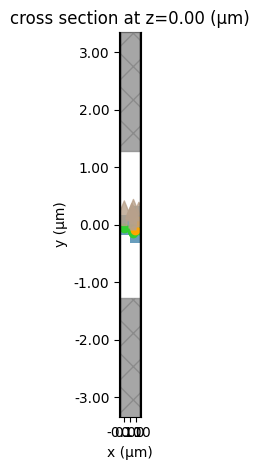

In [ ]:
params = {
    "period": period_bragg,
    "w_bragg_short": width_bragg_short,
    "w_bragg_long": width_bragg_long,
    "type_crystal": "uniform",
    "width_beam":  width_bragg_short,
}

# Simulation parameters
structures = make_cells(params)[0]
dipoles = make_cells(params)[1]
monitorsTime = make_cells(params)[2]
simSize = make_cells(params)[3]
bspecs = make_cells(params)[4]

# Symmetry to be applied in the simulation
symmetry = (0, 0, 1)


sim = td.Simulation(
    center=(0, 0, 0),
    size=simSize,
    grid_spec=td.GridSpec.auto(),
    structures=structures,
    sources=dipoles,
    monitors=monitorsTime,
    run_time=runtime,
    shutoff=0,
    boundary_spec=bspecs,
    normalize_index=None,
    symmetry=symmetry,
)

ax = sim.plot(z=0)
#ax.set_ylim(-0.5, 0.5)
plt.show()



In [ ]:
# Upload task
task_id = web.upload(sim, task_name="BCBands_uni")
# Run simulation
BCBands_uni = web.run(
    sim, "BCBands_uni", folder_name="data", path="data/BCBands_uni.hdf5", verbose=True
)

22:30:13 UTC Created task 'BCBands_uni' with resource_id                        
             'fdve-04d3b358-2c81-412e-bf91-dd1a9638949e' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=17996;https://tidy3d.simulation.cloud/workbench?taskId=fdve-04d3b358-2c81-412e-bf91-dd1a9638949e\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=271166;https://tidy3d.simulation.cloud/workbench?taskId=fdve-04d3b358-2c81-412e-bf91-dd1a9638949e\taskId]8;;\]8;id=17996;https://tidy3d.simulation.cloud/workbench?taskId=fdve-04d3b358-2c81-412e-bf91-dd1a9638949e\=]8;;\]8;id=608886;https://tidy3d.simulation.cloud/workbench?taskId=fdve-04d3b358-2c81-412e-bf91-dd1a9638949e\fdve]8;;\]8;id=17996;https://tidy3d.simulation.cloud/workbench?taskId=fdve-04d3b358-2c81-412e-bf91-dd1a9638949e\-04d3b358-2c8]8;;\
             ]8;id=17996;https://tidy3d.simulation.cloud/workbench?taskId=fdve-04d3b358-2c81-412e-bf91-dd1a9638949e\1-412e-bf91-dd1a9638949e']8;;\.

             Task folder: ]8;id=851314;https://tidy3d.simulation.cloud/folders/folder-a7b4ef25-6bcb-4f64-9241-809188799104\'default']8;;\.

Output()

22:30:14 UTC Estimated FlexCredit cost: 0.025. Minimum cost depends on task     
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

...

Output()

22:30:16 UTC Estimated FlexCredit cost: 0.025. Minimum cost depends on task     
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

             status = success

Output()

22:30:17 UTC Loading results from data/BCBands_uni.hdf5

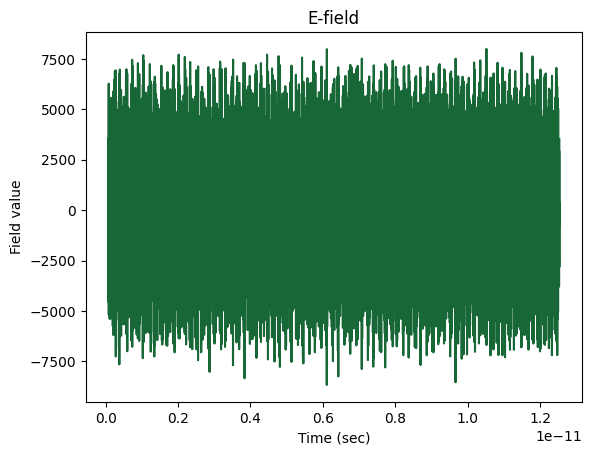

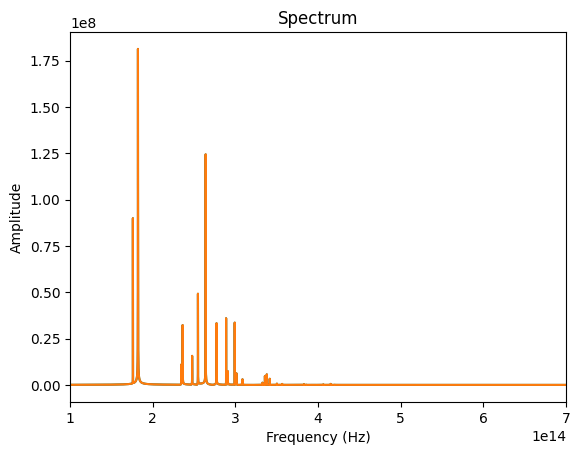

v0 = 1.9341e+14 Hz  →  1550000.0 nm
freqs range: 1.7607e+14 → 4.2018e+14 Hz
freqs en nm: ['1702.7', '1645.4', '1276.4', '1269.0', '1210.3', '1176.7', '1135.4', '1081.3', '1038.1', '1030.8', '1001.9', '995.1', '971.5', '900.9', '892.9', '886.9', '877.5', '855.8', '782.7', '770.1', '737.1', '721.9', '713.5']
Wavelength 1: 1645.36 nm
Wavelength 2: 1276.44 nm


In [ ]:
# Plotting E field as a function of time
plt.plot(
    BCBands_uni.monitor_data["monitor-time-0"].Ey.t,
    np.real(BCBands_uni.monitor_data["monitor-time-0"].Ey.squeeze()),
)
plt.xlabel("Time (sec)")
plt.ylabel("Field value")
plt.title("E-field")
plt.show()

# Plot spectra
time_series = np.real(BCBands_uni.monitor_data["monitor-time-0"].Ey.squeeze())
dt = BCBands_uni.simulation.dt
fmesh = np.fft.fftshift(np.fft.fftfreq(time_series.size, dt))
spectrum = np.fft.fftshift(np.fft.fft(time_series))
plt.plot(fmesh, np.abs(spectrum))

# Extracting the frequency spectrum
time_series = np.real(BCBands_uni.monitor_data["monitor-time-0"].Ey.squeeze()) # convert to a time series
dt = BCBands_uni.simulation.dt # simulation time step
fmesh = np.fft.fftshift(np.fft.fftfreq(time_series.size, dt)) #
spectrum = np.fft.fftshift(np.fft.fft(time_series))
plt.plot(fmesh, np.abs(spectrum))
plt.xlim(1e14, 7e14)
plt.title("Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.show()

# On the time signal to find the cavity's resonance frequencies within the window [window1, window2]
window1 = ss5
window2 = ss1
resonance_finder = ResonanceFinder(freq_window=tuple((window1, window2)))
resonance_data = resonance_finder.run(signals=BCBands_uni.data)

# Filter resonances
resonance_data_filtered = filter_resonances(
    resonance_data=resonance_data, minQ=100, minamp=0.001, maxerr=100
)
freqs = resonance_data_filtered.freq.to_numpy()

# Target frequency
target_lambda = 1550e-3
v0 = m_freq(target_lambda)

print(f"v0 = {v0:.4e} Hz  →  {freq_nm(v0) * 1e3} nm")
print(f"freqs range: {freqs.min():.4e} → {freqs.max():.4e} Hz")
print(f"freqs en nm: {[f'{freq_nm(f):.1f}' for f in freqs]}")

# Center frequency
v1_uni = None
v2_uni = None
for freq in freqs:
    if freq < v0:
        v1_uni = freq
    elif freq > v0:
        v2_uni = freq
        break

# Calculating band edges
print(f"Wavelength 1: {freq_nm(v1_uni):.2f} nm")
print(f"Wavelength 2: {freq_nm(v2_uni):.2f} nm")

### Find the bandgap for the imperefection

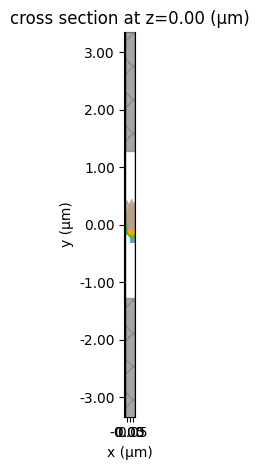

In [ ]:
params = {
    "number_p": number_p,
    "period": period_bragg,
    "w_bragg_short": width_bragg_short,
    "w_bragg_long": width_bragg_long,
    "type_crystal": "imperfection",
    "width_beam":  width_bragg_short,
}

# Simulation parameters
structures = make_cells(params)[0]
dipoles = make_cells(params)[1]
monitorsTime = make_cells(params)[2]
simSize = make_cells(params)[3]
bspecs = make_cells(params)[4]

# Symmetry to be applied in the simulation
symmetry = (0, 0, 1)


sim = td.Simulation(
    center=(0, 0, 0),
    size=simSize,
    grid_spec=td.GridSpec.auto(),
    structures=structures,
    sources=dipoles,
    monitors=monitorsTime,
    run_time=runtime,
    shutoff=0,
    boundary_spec=bspecs,
    normalize_index=None,
    symmetry=symmetry,
)

ax = sim.plot(z=0)
#ax.set_ylim(-0.5, 0.5)
plt.show()


In [ ]:
# Upload task
task_id = web.upload(sim, task_name="BCBands_imp")
# Run simulation
BCBands_imp = web.run(
    sim, "BCBands_imp", folder_name="data", path="data/BCBands_imp.hdf5", verbose=True
)

20:37:56 UTC Created task 'BCBands_imp' with resource_id                        
             'fdve-4e4ed960-d631-49db-be21-b2500579e48a' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=280229;https://tidy3d.simulation.cloud/workbench?taskId=fdve-4e4ed960-d631-49db-be21-b2500579e48a\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=673093;https://tidy3d.simulation.cloud/workbench?taskId=fdve-4e4ed960-d631-49db-be21-b2500579e48a\taskId]8;;\]8;id=280229;https://tidy3d.simulation.cloud/workbench?taskId=fdve-4e4ed960-d631-49db-be21-b2500579e48a\=]8;;\]8;id=272281;https://tidy3d.simulation.cloud/workbench?taskId=fdve-4e4ed960-d631-49db-be21-b2500579e48a\fdve]8;;\]8;id=280229;https://tidy3d.simulation.cloud/workbench?taskId=fdve-4e4ed960-d631-49db-be21-b2500579e48a\-4e4ed960-d63]8;;\
             ]8;id=280229;https://tidy3d.simulation.cloud/workbench?taskId=fdve-4e4ed960-d631-49db-be21-b2500579e48a\1-49db-be21-b2500579e48a']8;;\.

             Task folder: ]8;id=396863;https://tidy3d.simulation.cloud/folders/folder-a7b4ef25-6bcb-4f64-9241-809188799104\'default']8;;\.

Output()

20:38:10 UTC Estimated FlexCredit cost: 0.025. Minimum cost depends on task     
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

...

Output()

20:38:43 UTC status = success

20:38:45 UTC View simulation result at                                          
             ]8;id=684119;https://tidy3d.simulation.cloud/workbench?taskId=fdve-f07c60f8-276a-4018-96b9-8296dcab0f30\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=408595;https://tidy3d.simulation.cloud/workbench?taskId=fdve-f07c60f8-276a-4018-96b9-8296dcab0f30\taskId]8;;\]8;id=684119;https://tidy3d.simulation.cloud/workbench?taskId=fdve-f07c60f8-276a-4018-96b9-8296dcab0f30\=]8;;\]8;id=259742;https://tidy3d.simulation.cloud/workbench?taskId=fdve-f07c60f8-276a-4018-96b9-8296dcab0f30\fdve]8;;\]8;id=684119;https://tidy3d.simulation.cloud/workbench?taskId=fdve-f07c60f8-276a-4018-96b9-8296dcab0f30\-f07c60f8-276]8;;\
             ]8;id=684119;https://tidy3d.simulation.cloud/workbench?taskId=fdve-f07c60f8-276a-4018-96b9-8296dcab0f30\a-4018-96b9-8296dcab0f30']8;;\.

Output()

20:38:48 UTC Loading results from data/BCBands_imp.hdf5

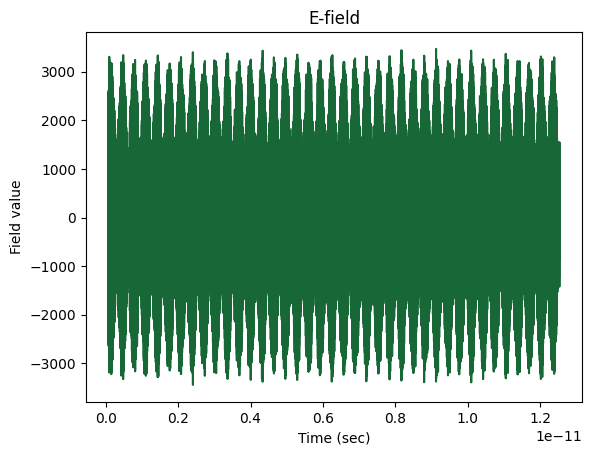

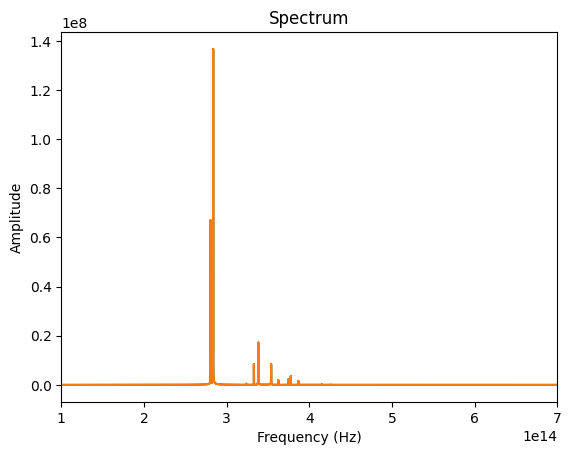

v0 = 1.9341e+14 Hz  →  1550000.0 nm
freqs range: 2.8062e+14 → 4.2750e+14 Hz
freqs en nm: ['1068.3', '1056.6', '926.6', '924.9', '900.2', '886.3', '847.2', '827.1', '800.0', '793.8', '775.9', '775.4', '722.1', '706.0', '701.3']


TypeError: unsupported operand type(s) for /: 'float' and 'NoneType'

In [ ]:
# Plotting E field as a function of time
plt.plot(
    BCBands_imp.monitor_data["monitor-time-0"].Ey.t,
    np.real(BCBands_imp.monitor_data["monitor-time-0"].Ey.squeeze()),
)
plt.xlabel("Time (sec)")
plt.ylabel("Field value")
plt.title("E-field")
plt.show()

# Plot spectra
time_series = np.real(BCBands_imp.monitor_data["monitor-time-0"].Ey.squeeze())
dt = BCBands_imp.simulation.dt
fmesh = np.fft.fftshift(np.fft.fftfreq(time_series.size, dt))
spectrum = np.fft.fftshift(np.fft.fft(time_series))
plt.plot(fmesh, np.abs(spectrum))

time_series = np.real(BCBands_imp.monitor_data["monitor-time-0"].Ey.squeeze())
dt = BCBands_imp.simulation.dt
fmesh = np.fft.fftshift(np.fft.fftfreq(time_series.size, dt))
spectrum = np.fft.fftshift(np.fft.fft(time_series))
plt.plot(fmesh, np.abs(spectrum))
plt.xlim(1e14, 7e14)
plt.title("Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.show()

# On the time signal to find the cavity's resonance frequencies within the window [window1, window2]
window1 = ss5
window2 = ss1
resonance_finder = ResonanceFinder(freq_window=tuple((window1, window2)))
resonance_data = resonance_finder.run(signals=BCBands_imp.data)

# Filter resonances
resonance_data_filtered = filter_resonances(
    resonance_data=resonance_data, minQ=100, minamp=0.001, maxerr=100
)
freqs = resonance_data_filtered.freq.to_numpy()

# Target frequency
target_lambda = 1550e-3
v0 = m_freq(target_lambda)

print(f"v0 = {v0:.4e} Hz  →  {freq_nm(v0) * 1e3} nm")
print(f"freqs range: {freqs.min():.4e} → {freqs.max():.4e} Hz")
print(f"freqs en nm: {[f'{freq_nm(f):.1f}' for f in freqs]}")

# Center frequency
v1 = None
v2 = None
for freq in freqs:
    if freq < v0:
        v1 = freq
    elif freq > v0:
        v2 = freq
        break

# Calculating band edges
print(f"Wavelength 1: {freq_nm(v1):.2f} nm")
print(f"Wavelength 2: {freq_nm(v2):.2f} nm")

### Bragg crystal simulation

For a Bragg crystal with a uniform structure, the reflection band is in:

* $\lambda_1 = 1645.36 nm$
* $\lambda_2 = 1276.44 nm$

In contrast, introducing an imperfection into the Bragg crystal lattice results in allowed wavelengths within the reflection band, given by:

* $\lambda_{imper_1} = 703.11 nm$
* $\lambda_{imper_2} = 692.11 nm$

In [ ]:
def make_bragg_prog(
    params: dict,
):
    """
    Create a simulation of a Bragg crystal with an imperfection introduced in its central region,
    implemented using the Tidy3D electromagnetic simulation platform.

    Parameters
    ----------
    params : dict
        Dictionary containing the simulation parameters:
        - number_p (int): Number of periods in the Bragg crystal.
        - period (float): Lattice constant (periodicity) of the structure along x.
        - w_bragg_short (float): Width of the narrow section of the Bragg unit cell.
        - w_bragg_long (float): Width of the wide section of the Bragg unit cell.
        - type_crystal (str): Type of crystal to generate. Options:
            "uniform" or other (introduces imperfections).
        - width_beam (float): Width along the y-axis where dipole sources
            and monitors are randomly distributed.
        - imperfection (bool): Whether to introduce an imperfection in the Bragg crystal.

    Description
    -----------
    This function:
    1. Generates a Bragg crystal structure (uniform or with imperfections).
    2. Randomly distributes dipole sources within one unit cell.
    3. Assigns random phases to each dipole source.
    4. Places time-domain field monitors at random positions.
    5. Defines boundary conditions:
        - Bloch boundary in x (periodic with phase shift π).
        - PML boundaries in y and z (absorbing boundaries).
    6. Defines the simulation domain size.

    Returns
    -------
    list
        A list containing:
        - structures (list): List of Tidy3D structures (Bragg crystal).
        - dipoles (list): List of dipole sources.
        - monitorsTime (list): List of time-domain field monitors.
        - simSize (tuple): Simulation domain size (x, y, z).
        - bspecs (td.BoundarySpec): Boundary conditions of the simulation.
    """
    number_p =params["number_p"]
    period = params["period"]
    width_bragg_short = params["w_bragg_short"]
    width_bragg_long = params["w_bragg_long"]
    imperfection = params["imperfection"]
    core_medium = params["core_medium"]
    wg_length = params["wg_length"]
    central_freq = params["central_freq"]
    freq_width = params["freq_width"]

    # =====================================================
    #            Creation of the Bragg Crystal
    # =====================================================
    # Length of the each bragg crystal
    length_bragg = period / 2
    total_length_bragg = period * number_p / 2

    # Total length of the bragg crystal + imperfection
    crystal_length = 2 * period * number_p + period / 2

    list_structures = [] # List of the structures

    if imperfection:
        # Imperfection in the Bragg crystal
        imper_short = td.Structure(
            geometry=td.Box.from_bounds(
              rmin=(-length_bragg / 2, -(width_bragg_short / 2), 0),
              rmax=(0, (width_bragg_short / 2), wg_height)
            ),
            medium=core_medium,
        )
        imper_long = td.Structure(
            geometry=td.Box.from_bounds(
              rmin=(0, -(width_bragg_long / 2), 0),
              rmax=(length_bragg / 2, (width_bragg_long / 2), wg_height)
            ),
            medium=core_medium,
        )
        list_structures.append(imper_short)
        list_structures.append(imper_long)

        # Bragg down
        for i in range(0, number_p):
          short_bragg = td.Structure(
              geometry=td.Box.from_bounds(
                  rmin=(
                      ((length_bragg) * 2 * i) - (total_length_bragg * 2 + length_bragg / 2),
                      -(width_bragg_short / 2),
                      0
                  ),
                  rmax=(
                      ((length_bragg) * (2 * i + 1)) - (total_length_bragg * 2 + length_bragg / 2),
                      (width_bragg_short / 2),
                      wg_height
                  )
              ),
              medium=core_medium,
          )

          long_bragg = td.Structure(
              geometry=td.Box.from_bounds(
                  rmin=(
                      ((length_bragg) * (2 * i + 1)) - (total_length_bragg * 2 + length_bragg / 2),
                      -(width_bragg_long / 2),
                      0
                  ),
                  rmax=(
                      (length_bragg) + ((length_bragg) * (2 * i + 1)) - (total_length_bragg * 2 + length_bragg / 2),
                      (width_bragg_long / 2),
                      wg_height
                  )
              ),
              medium=core_medium,
          )

          list_structures.append(short_bragg)
          list_structures.append(long_bragg)

        # Bragg up
        for i in range(0, number_p):
          short_bragg = td.Structure(
              geometry=td.Box.from_bounds(
                  rmin=(
                      ((length_bragg) * 2 * i) + (length_bragg / 2),
                      -(width_bragg_short / 2),
                      0,
                  ),
                  rmax=(
                      ((length_bragg) * (2 * i + 1)) + (length_bragg / 2),
                      (width_bragg_short / 2),
                      wg_height,
                  )
              ),
              medium=core_medium,
          )

          long_bragg = td.Structure(
              geometry=td.Box.from_bounds(
                  rmin=(
                      ((length_bragg) * (2 * i + 1)) + (length_bragg / 2),
                      -(width_bragg_long / 2),
                      0,
                  ),
                  rmax=(
                      (length_bragg) + ((length_bragg) * (2 * i + 1)) + (length_bragg / 2),
                      (width_bragg_long / 2),
                      wg_height,
                  )
              ),
              medium=core_medium,
          )

          list_structures.append(short_bragg)
          list_structures.append(long_bragg)

        # Waveguides
        wg_down = td.Structure(
            geometry=td.Box.from_bounds(
              rmin=(
                  - (total_length_bragg * 2 + length_bragg / 2 + wg_length),
                  -(wg_width / 2),
                  0
              ),
              rmax=(
                  - (total_length_bragg * 2 + length_bragg / 2),
                  (wg_width / 2),
                  wg_height
              )
            ),
            medium=core_medium,
        )
        list_structures.append(wg_down)

        wg_up = td.Structure(
            geometry=td.Box.from_bounds(
              rmin=(
                  (total_length_bragg * 2 + length_bragg / 2),
                  -(wg_width / 2),
                  0
              ),
              rmax=(
                  (total_length_bragg * 2 + length_bragg / 2 + wg_length),
                  (wg_width / 2),
                  wg_height
              )
            ),
            medium=core_medium,
        )
        list_structures.append(wg_up)

        # Total length of the bragg crystal + imperfection
        crystal_length = 2 * period * number_p + period / 2
    else:
        wg_down = td.Structure(
            geometry=td.Box.from_bounds(
              rmin=(
                  - wg_length,
                  -(wg_width / 2),
                  0
              ),
              rmax=(
                  - total_length_bragg,
                  (wg_width / 2),
                  wg_height
              )
            ),
            medium=core_medium,
        )
        list_structures.append(wg_down)

        wg_up = td.Structure(
            geometry=td.Box.from_bounds(
              rmin=(
                  total_length_bragg,
                  -(wg_width / 2),
                  0
              ),
              rmax=(
                  wg_length,
                  (wg_width / 2),
                  wg_height
              )
            ),
            medium=core_medium,
        )
        list_structures.append(wg_up)

        for i in range(0, number_p):
          short_bragg = td.Structure(
              geometry=td.Box.from_bounds(
                  rmin=(
                      (length_bragg) * 2 * i - total_length_bragg
                      -(width_bragg_short / 2),
                      0
                  ),
                  rmax=(
                      (length_bragg) * (2 * i + 1) - total_length_bragg,
                      (width_bragg_short / 2),
                      wg_height
                  )
              ),
              medium=core_medium,
          )

          long_bragg = td.Structure(
              geometry=td.Box.from_bounds(
                  rmin=(
                      (length_bragg) * (2 * i + 1) - total_length_bragg
                      -(width_bragg_long / 2),
                      0
                  ),
                  rmax=(
                      (length_bragg) + (length_bragg) * (2 * i + 1) - total_length_bragg,
                      (width_bragg_long / 2),
                      wg_height
                  )
              ),
              medium=core_medium,
          )

          list_structures.append(short_bragg)
          list_structures.append(long_bragg)
        # Total length of the bragg crystal
        crystal_length = period * number_p

    # Combine the structures
    # combined_structure = td.Structure(
    #     geometry=td.GeometryGroup(geometries= [s.geometry for s in list_structures]),
    #     medium=core_medium
    # )

    # ================================================
    #        Set up yhe sources and the monitors
    # ================================================
    # Set up the source
    source = td.PointDipole(
        center=(0, 0, 0), # center of the source
        source_time=td.GaussianPulse(  # define the source's time profile, a frequency-modulated Gaussian pulse
            freq0=central_freq, # center frequency of the pulse
            fwidth=freq_width # frequency-dependent pulse width
            ),
        polarization="Ey", # the direction in which the electric field of the dipole oscillates
    )

    # Set up the field monitor
    point_t_mnt = td.FieldTimeMonitor(
        center=[0, 0, 0],
        size=[0, 0, 0],
        start=tstart,
        name="point",
        colocate=True,  # Colocate so field is colocated to grid cell centers
    )

    field_t_mnt = td.FieldTimeMonitor(
        center=[0, 0, 0],
        size=[td.inf, td.inf, td.inf],
        start=runtime,
        name="field",
        colocate=True,
    )

    # Permitivity monitor
    eps_mnt = td.PermittivityMonitor(
        center=[0, 0, 0], size=[td.inf, td.inf, td.inf], freqs=[central_freq], name="eps"
    )

    # Simulation boundery conditions
    bspecs = td.BoundarySpec(
        x=td.Boundary.pml(),
        y=td.Boundary.pml(),
        z=td.Boundary.pml()
    )

    # Simulation size
    simSize = (
        2 * crystal_length,
        width_bragg_long * 5,
        4
    )

    return [list_structures, simSize, bspecs, source, point_t_mnt, field_t_mnt, eps_mnt]


In [ ]:
center_wv = 1600
center_freq = td.C_0 / (center_wv * 1e-3)
# center_freq = (v1_uni + v2_uni) / 2
# center_wv = freq_nm(center_freq)

params = {
    "number_p": number_p,
    "period": period_bragg,
    "w_bragg_short": width_bragg_short,
    "w_bragg_long": width_bragg_long,
    "imperfection": True,
    "core_medium": Si,
    "wg_length": 100,
    "central_freq": center_freq,
    "freq_width": ssWidth,
}

simsetup = make_bragg_prog(params)

structures = simsetup[0]
simSize = simsetup[1]
bspecs = simsetup[2]
source = simsetup[3]
point_t_mnt = simsetup[4]
field_t_mnt = simsetup[5]
eps_mnt = simsetup[6]
symmetry = (1, -1, 1)


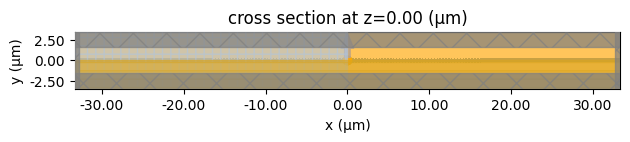

In [ ]:
mesh_override = td.MeshOverrideStructure(
    geometry=td.Box(center=(0, 0, 0), size=(0.5, 0.5, 0.5 * 1.5)), dl=[0.01, 0.01, 0.01]
)

# Define grid specification for the simulation
grid_spec = td.GridSpec.auto(
    min_steps_per_wvl=10,
    override_structures=[mesh_override],
)


sim = td.Simulation(
    center=(0, 0, 0),
    size=simSize,
    grid_spec=td.GridSpec.auto(),
    structures=structures,
    sources=[source],
    monitors=[point_t_mnt, field_t_mnt, eps_mnt],
    run_time=runtime,
    shutoff=0,
    boundary_spec=bspecs,
    normalize_index=None,
    symmetry=symmetry,
)

sim.plot(z=0)
plt.show()

In [ ]:
# Upload task
task_id = web.upload(sim, task_name="BraggCrystal")
# Run simulation
BraggCrystalData = web.run(
    sim, "BraggCrystal", folder_name="data", path="data/BraggCrystal.hdf5", verbose=True
)

21:44:41 UTC Created task 'BraggCrystal' with resource_id                       
             'fdve-1b611589-e8c8-4043-a0a2-069fa6def464' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=636082;https://tidy3d.simulation.cloud/workbench?taskId=fdve-1b611589-e8c8-4043-a0a2-069fa6def464\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=687575;https://tidy3d.simulation.cloud/workbench?taskId=fdve-1b611589-e8c8-4043-a0a2-069fa6def464\taskId]8;;\]8;id=636082;https://tidy3d.simulation.cloud/workbench?taskId=fdve-1b611589-e8c8-4043-a0a2-069fa6def464\=]8;;\]8;id=311481;https://tidy3d.simulation.cloud/workbench?taskId=fdve-1b611589-e8c8-4043-a0a2-069fa6def464\fdve]8;;\]8;id=636082;https://tidy3d.simulation.cloud/workbench?taskId=fdve-1b611589-e8c8-4043-a0a2-069fa6def464\-1b611589-e8c]8;;\
             ]8;id=636082;https://tidy3d.simulation.cloud/workbench?taskId=fdve-1b611589-e8c8-4043-a0a2-069fa6def464\8-4043-a0a2-069fa6def464']8;;\.

             Task folder: ]8;id=136693;https://tidy3d.simulation.cloud/folders/folder-a7b4ef25-6bcb-4f64-9241-809188799104\'default']8;;\.

Output()

21:44:44 UTC Estimated FlexCredit cost: 0.099. Minimum cost depends on task     
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

...

Output()

21:46:28 UTC status = success

21:46:30 UTC View simulation result at                                          
             ]8;id=752951;https://tidy3d.simulation.cloud/workbench?taskId=fdve-d82aab7a-c91f-46fa-b978-a2579cb4f3c6\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=281252;https://tidy3d.simulation.cloud/workbench?taskId=fdve-d82aab7a-c91f-46fa-b978-a2579cb4f3c6\taskId]8;;\]8;id=752951;https://tidy3d.simulation.cloud/workbench?taskId=fdve-d82aab7a-c91f-46fa-b978-a2579cb4f3c6\=]8;;\]8;id=374809;https://tidy3d.simulation.cloud/workbench?taskId=fdve-d82aab7a-c91f-46fa-b978-a2579cb4f3c6\fdve]8;;\]8;id=752951;https://tidy3d.simulation.cloud/workbench?taskId=fdve-d82aab7a-c91f-46fa-b978-a2579cb4f3c6\-d82aab7a-c91]8;;\
             ]8;id=752951;https://tidy3d.simulation.cloud/workbench?taskId=fdve-d82aab7a-c91f-46fa-b978-a2579cb4f3c6\f-46fa-b978-a2579cb4f3c6']8;;\.

Output()

21:46:31 UTC Loading results from data/BraggCrystal.hdf5

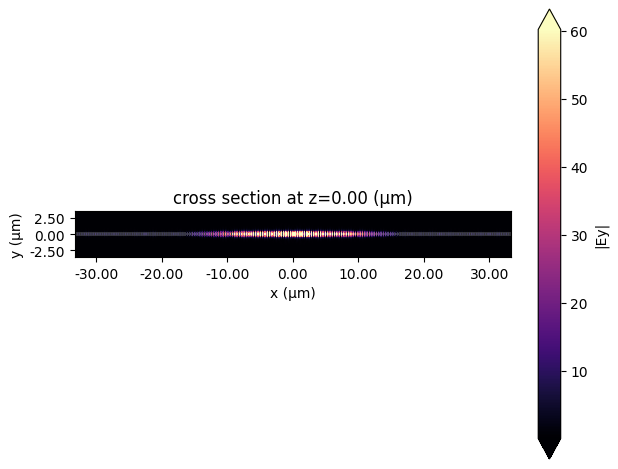

In [ ]:
# Plotting E field at very end of simulation
final_time = BraggCrystalData["field"].Ey.t
BraggCrystalData.plot_field("field", "Ey", val="abs", t=final_time, z=0)

plt.savefig(f"Ey_field_central-freq_{center_wv}.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# Get y-component of E field from point monitor
time_series = BraggCrystalData["point"].Ey.squeeze()

# Run resonance finder
resonance_finder = ResonanceFinder(freq_window=tuple((ss4, ss3)))
resonance_data = resonance_finder.run_scalar_field_time(time_series)
resonance_data_filtered = filter_resonances(
    resonance_data=resonance_data, minQ=100, minamp=0.001, maxerr=100
)

# Cavity mode with highest Q from filtered resonances
freqcav, Q = cavitymode(resonance_data_filtered)

print(f"Resonance frequency: {freq_nm(freqcav):.2f} nm")
print(f"Quality Factor: {Q}")

Resonance frequency: 1607.24 nm
Quality Factor: -109.76593721849912


---
# Fabry-Perot type microcavity

This part of the program is based on the article: "*Enhanced nonlinear interaction in a microcavity under coherent excitation*".

File path: `C:\Users\samhu\Documents\Maestria\Diseño_de_Circuitos_Fotonicos_Integrados\Proyecto`

* A 4 section holes with a 200 nm diameter and a 370 nm periodicity constant.

* The taper hole diameters are 130, 160, 190 and 200 nm with the center-to-center hole distances set to 320, 340, 360 and 370 nm.

* The distance between the centers of the two-inner holes of the cavity is set to 450 nm in order to localize the cavity resonance nearby λ = 1580 nm.

* The calculated modal volume of the designed cavity is V = 0.8(λ /n)3, with n = 3.48 the refractive index of
silicon.

* FSR = $2.5 mm$

* Cavity resonance at $1578.8 nm$

* FWHM: $\Delta \lambda_0 = 0.271 nm$

* Quality factor: $Q = 7275$

In [ ]:
# Geometry of the waveguide
wg_height = 0.26
wg_width = 0.52

# Geometry of the 4 section holes of the Fabry-Perot microcavity
diameter_holes_FP = [0.13, 0.16, 0.19, 0.2]
distance_center_hole = [0, 0.32, 0.34, 0.36, 0.37]

# Distance of the two center holes
d_center_holes_uni = 0.45

In [ ]:
# --- Function for creating circular unit cells ---
def circle_uc(center, diameter, height=0.5):
    radius = diameter / 2
    theta = np.linspace(0, np.pi * 2, 1001)
    x = radius * np.cos(theta) + center[0]
    y = radius * np.sin(theta) + center[1]

    geometry = td.PolySlab(
        vertices=np.array([x, y]).T,
        slab_bounds=(-height / 2 + center[2], height / 2 + center[2]),
        axis=2,
    )
    return geometry

In [ ]:
def fabry_perot_microcavity(
    params: dict,
):
    """
    Builds the components of a photonic Fabry-Perot microcavity in a waveguide
    with circular holes, ready to be used in a Tidy3D FDTD simulation.

    Parameters
    ----------
    params : dict
        Configuration dictionary with the following keys:

        - wg_height        : float
            Height (Z-axis) of the waveguide.
        - wg_width         : float
            Width (Y-axis) of the waveguide.
        - wg_medium        : td.Medium
            Material/medium of the waveguide.
        - holes_medium     : td.Medium
            Material/medium of the holes (typically air).
        - diameter_list_holes : list[float]
            List of hole diameters forming the mirror regions
            (created symmetrically on both sides of the cavity).
        - distance_center_holes : float
            Distance from the cavity center to the first hole.
        - center_center_distance : list[float]
            List of center-to-center distances between consecutive holes.
            Its length must match that of `diameter_list_holes`.
        - number_holes : int
            Number of holes in the cavity.
        - central_freq     : float
            Center frequency of the Gaussian source pulse [Hz].
        - freq_width       : float
            Spectral width of the Gaussian source pulse [Hz].

    Returns
    -------
    list
        A list containing the following 7 elements in order:

        [0] structures    : list[td.Structure]
            List of structures composing the simulation:
            · The rectangular waveguide centered at the origin.
            · Variable holes (left and right) defined by
              `diameter_list_holes` and `center_center_distance`.
            · 4 additional constant hole pairs at the end of each mirror,
              using the last diameter and last distance from the lists.

        [1] simSize       : tuple[float, float, float]
            Simulation box size (x=10, y=wg_width, z=wg_height).

        [2] bspecs        : td.BoundarySpec
            Perfectly Matched Layer (PML) boundary conditions on all three axes.

        [3] source        : td.PointDipole
            Point dipole at the cavity center (0,0,0), polarized along Ey,
            with a Gaussian time profile defined by `central_freq` and `freq_width`.

        [4] point_t_mnt   : td.FieldTimeMonitor
            Point time-domain field monitor at the center (0,0,0), active from `tstart`.

        [5] field_t_mnt   : td.FieldTimeMonitor
            Time-domain field monitor over the entire simulation domain,
            active from `runtime`.

        [6] eps_mnt       : td.PermittivityMonitor
            Permittivity monitor over the entire domain at `central_freq`.

    Notes
    -----
    - The function depends on the global variables `tstart` and `runtime`.
    - Holes are created using the helper function `circle_uc(center, diameter, height)`.
    - The cavity is centered at the origin; the mirrors extend symmetrically along ±X.
    """
    # ================================================================
    #                      Definition of the variables
    # ================================================================
    wg_height = params["wg_height"]
    wg_width = params["wg_width"]
    wg_medium = params["wg_medium"]
    holes_medium = params["holes_medium"]
    diameter_list_holes = params["diameter_list_holes"]
    distance_center_holes = params["distance_center_holes"]
    center_center_distance = params["center_center_distance"]
    polarization_source = params["polarization_source"]
    wg_length = params["wg_length"]
    number_holes = params["number_holes"]
    central_freq = params["central_freq"]
    freq_width = params["freq_width"]

    # ===============================================================
    #             Creating the Fabry-Perot microcavity
    # ===============================================================
    structures = []
    # Waveguide
    wg = td.Structure(
        geometry= td.Box(
            center=(0,0,0),
            size=(wg_length, wg_width, wg_height)
        ),
        medium=wg_medium,
        name="waveguide"
    )
    structures.append(wg)

    position_x = distance_center_holes / 2

    # Making the center holes
    for i, diameter in enumerate(diameter_list_holes):
      position_x += center_center_distance[i]
      hole_left = td.Structure(
        geometry=circle_uc(
          center=(position_x, 0, 0),
          diameter=diameter,
          height=wg_height
        ),
        medium=holes_medium,
        name="hole_" + str(i) + "_left"
      )
      hole_right = td.Structure(
        geometry=circle_uc(
          center=(-(position_x), 0, 0),
          diameter=diameter,
          height=wg_height
        ),
        medium=holes_medium,
        name="hole_" + str(i) + "_right"
      )
      structures.append(hole_left)
      structures.append(hole_right)

    for i in range(0, number_holes):
      position_x += center_center_distance[-1]

      hole_l = td.Structure(
        geometry=circle_uc(
          center=(position_x, 0, 0),
          diameter=diameter_list_holes[-1],
          height=wg_height
        ),
        medium=holes_medium,
        name="hole_" + str(i) + "_left_const"
      )
      hole_r = td.Structure(
        geometry=circle_uc(
          center=(-position_x, 0, 0),
          diameter=diameter_list_holes[-1],
          height=wg_height
        ),
        medium=holes_medium,
        name="hole_" + str(i) + "_right_const"
      )
      structures.append(hole_l)
      structures.append(hole_r)

    # ================================================
    #        Set up yhe sources and the monitors
    # ================================================
    # Set up the source
    source = td.PointDipole(
        center=(0, 0, 0), # center of the source
        source_time=td.GaussianPulse(  # define the source's time profile, a frequency-modulated Gaussian pulse
            freq0=central_freq, # center frequency of the pulse
            fwidth=freq_width # frequency-dependent pulse width
            ),
        polarization=polarization_source, # the direction in which the electric field of the dipole oscillates
    )

    # Set up the field monitor
    point_t_mnt = td.FieldTimeMonitor(
        center=[0, 0, 0],
        size=[0, 0, 0],
        start=tstart,
        name="point",
        colocate=True,  # Colocate so field is colocated to grid cell centers
    )

    field_t_mnt = td.FieldTimeMonitor(
        center=[0, 0, 0],
        size=[td.inf, td.inf, td.inf],
        start=runtime,
        name="field",
        colocate=True,
    )

    # Permitivity monitor
    eps_mnt = td.PermittivityMonitor(
        center=[0, 0, 0],
        size=[td.inf, td.inf, td.inf],
        freqs=[central_freq],
        name="eps"
    )

    # Simulation boundery conditions
    bspecs = td.BoundarySpec(
        x=td.Boundary.pml(),
        y=td.Boundary.pml(),
        z=td.Boundary.pml()
    )
    # ============================
    #       Simulation size
    # ============================
    # Change the units of the central wavelength


    # Padding for the simulation boundaries
    padding_x =
    padding_y =
    padding_z =

    # Make the simulation boundaries
    simSize = (
        wg_length + padding_x,  # X-axis
        wg_width + padding_y,   # Y-axis
        wg_height + padding_z   # Z-axis
    )

    return [structures, simSize, bspecs, source, point_t_mnt, field_t_mnt, eps_mnt]


In [ ]:
# Frequency range of interest
ssWidth = 149999999997498 / 2.35

# Runtime
runtime = 800 / ssWidth
tstart = 5 / ssWidth

params_FP = {
    "wg_height": wg_height,
    "wg_width": wg_width,
    "wg_medium": Si,
    "holes_medium": Air,
    "diameter_list_holes": diameter_holes_FP,
    "distance_center_holes": d_center_holes_uni,
    "center_center_distance": distance_center_hole,
    "number_holes": 4,
    "central_freq": td.C_0 / (1580e-3),
    "freq_width": ssWidth,
    "wg_length": 10,
    "polarization_source": "Ey",
}


structures = fabry_perot_microcavity(params_FP)[0]
simSize = fabry_perot_microcavity(params_FP)[1]
bspecs = fabry_perot_microcavity(params_FP)[2]
source = fabry_perot_microcavity(params_FP)[3]
point_t_mnt = fabry_perot_microcavity(params_FP)[4]
field_t_mnt = fabry_perot_microcavity(params_FP)[5]
eps_mnt = fabry_perot_microcavity(params_FP)[6]

mesh_override = td.MeshOverrideStructure(
    geometry=td.Box(
        center=(0, 0, 0),
        size=(0.5, 0.5, 0.5 * 1.5)),
    dl=[0.01, 0.01, 0.01]
)

# Define grid specification for the simulation
grid_spec = td.GridSpec.auto(
    min_steps_per_wvl=10,
    override_structures=[mesh_override],
)

sim = td.Simulation(
    center=(0, 0, 0),
    size=simSize,
    grid_spec=grid_spec,
    structures=structures,
    sources=[source],
    monitors=[point_t_mnt, field_t_mnt, eps_mnt],
    run_time=runtime,
    shutoff=0,
    boundary_spec=bspecs,
    normalize_index=None,
    # symmetry=symmetry,
)

18:12:26 UTC WARNING: Structure: 'hole_0_left' (simulation.structures[1]) was   
             detected as being less than half of a central wavelength from a PML
             on side y-min. To avoid inaccurate results or divergence, please   
             increase gap between any structures and PML or fully extend        
             structure through the pml.                                         

             WARNING: Suppressed 31 WARNING messages.                           

In [ ]:
sim.plot_3d(width=1000, height=500)

In [ ]:
# Convert structure to gds
file_name = f"fabry-perot_microcavity.gds"
sim.to_gds_file(fname=file_name, z=0, permittivity_threshold=6, frequency=200e14)


###

In [ ]:
# Upload the task in tidy3d
task_id = web.upload(sim, task_name="FabryPerotMicrocavity")
# Run simulation
FPMicroData = web.run(
    sim,
    "FabryPerotMicrocavity",
    path="data/FabryPerotMicrocavity.hdf5",
    verbose=True,
)

00:36:43 UTC WARNING: Structure: 'waveguide' (simulation.structures[0]) was     
             detected as being less than half of a central wavelength from a PML
             on side y-min. To avoid inaccurate results or divergence, please   
             increase gap between any structures and PML or fully extend        
             structure through the pml.                                         

             WARNING: Suppressed 33 WARNING messages.                           

             Created task 'FabryPerotMicrocavity' with resource_id              
             'fdve-a95be45d-8f2c-41f1-8304-3a345ec16947' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=900956;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a95be45d-8f2c-41f1-8304-3a345ec16947\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=439205;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a95be45d-8f2c-41f1-8304-3a345ec16947\taskId]8;;\]8;id=900956;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a95be45d-8f2c-41f1-8304-3a345ec16947\=]8;;\]8;id=919710;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a95be45d-8f2c-41f1-8304-3a345ec16947\fdve]8;;\]8;id=900956;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a95be45d-8f2c-41f1-8304-3a345ec16947\-a95be45d-8f2]8;;\
             ]8;id=900956;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a95be45d-8f2c-41f1-8304-3a345ec16947\c-41f1-8304-3a345ec16947']8;;\.

             Task folder: ]8;id=494549;https://tidy3d.simulation.cloud/folders/folder-a7b4ef25-6bcb-4f64-9241-809188799104\'default']8;;\.

...

Output()

00:37:17 UTC Loading results from data/FabryPerotMicrocavity.hdf5

00:37:18 UTC WARNING: Structure: 'waveguide' (simulation.structures[0]) was     
             detected as being less than half of a central wavelength from a PML
             on side y-min. To avoid inaccurate results or divergence, please   
             increase gap between any structures and PML or fully extend        
             structure through the pml.                                         

             WARNING: Suppressed 33 WARNING messages.                           

             WARNING: The simulation has diverged! For more information, check  
             'SimulationData.log' or use 'web.download_log(task_id)'.           

TypeError: No numeric data to plot.

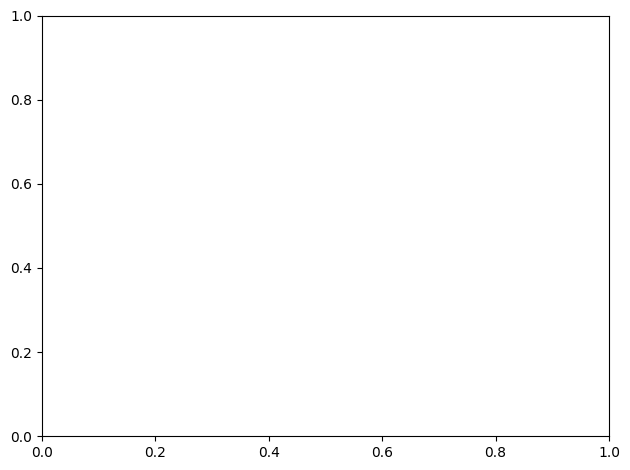

In [ ]:
# Plotting E field at very end of simulation
final_time = FPMicroData["field"].Ey.t
FPMicroData.plot_field("field", "Ey", val="abs", t=final_time, z=0)

plt.show()
